# Lab 8 — Reproducing Category 3 from scratch

**Maths for Post-Quantum Cryptography**, Chapter 8: *How Hard Is It Really?*

---

Four pieces. Part A implements the Geometric Series Assumption's
$\delta(\beta)$ formula. Part B implements Derivation 8.2's primal-attack
success condition and searches for the smallest BKZ block size $\beta$
that breaks each ML-KEM parameter set, reproducing Table 8.1's published
numbers from nothing but $(n,k,q,\eta_1)$. Part C converts each $\beta$
to a classical and quantum bit cost. Part D measures exactly how far the
raw core-SVP number sits below NIST's actual category threshold, and how
much larger $\beta$ would need to be to close that gap on the raw number
alone.

No SageMath, no external lattice-estimator package — every formula in
Chapter 8 is implemented directly, from the Geometric Series Assumption
through the core-SVP cost model. The published Kyber specification's
Table 4 numbers are used only as the comparison this lab is trying to
reproduce, never as an input.

**Part A — the GSA curve.** $\delta(\beta)$, and confirmation it
decreases monotonically toward 1.

**Part B — solving for $\beta$.** Derivation 8.2's success condition,
searched over $m$ and $\beta$, for all three ML-KEM parameter sets.

**Part C — Table 8.1, reproduced.** Classical and quantum bit costs from
each recovered $\beta$.

**Part D — how much margin, really.** Raw core-SVP cost vs. NIST's
category threshold, and the $\beta$ gap between them.

### Requirements

```
python >= 3.9
numpy
matplotlib
```

Nothing else — this is the entire point of the lab: the core-SVP
methodology is simple enough to implement from the chapter's own
formulas, without depending on a large external tool.

### How to use this notebook

Run it top to bottom once. Worked solutions for the pencil-and-paper
exercises (8.1-8.8, 8.12) are in Appendix C of the book.

Every section ends with `assert` statements, and the final cell is a
single `_selftest()` that repeats all of them. CI runs this notebook on
every commit; if an assertion fires on your machine, that is a bug in the
lab, not in your understanding — please open an issue.

In [1]:
from __future__ import annotations

import math

import numpy as np
import matplotlib.pyplot as plt

# Same print-safe, black-and-white styling as Labs 1-7.
plt.rcParams.update({
    "figure.figsize": (7.5, 3.4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.prop_cycle": plt.cycler(color=["0.15", "0.45", "0.65"]),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

print(f"numpy {np.__version__}")

numpy 2.4.4


---

## Part A — the GSA curve

Definition 8.3's Geometric Series Assumption predicts the shape of a
BKZ-$\beta$-reduced basis through a single parameter, $\delta(\beta)$.
Larger $\beta$ should give smaller $\delta$ — a better-reduced basis,
closer to $\delta=1$.

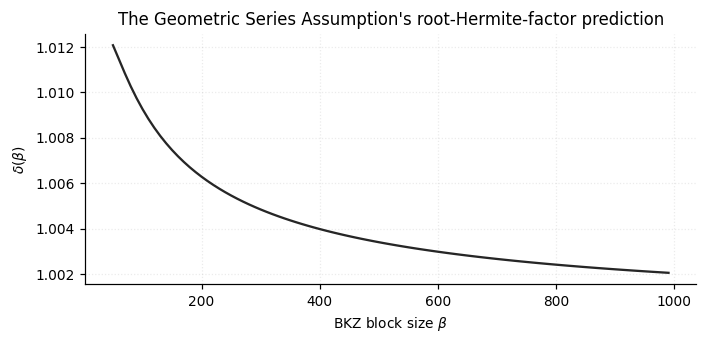

delta(50) = 1.012065, delta(400) = 1.003982, delta(900) = 1.002212
confirmed: delta(beta) decreases monotonically toward 1


In [2]:
def delta_gsa(beta):
    """Definition 8.3: the Geometric Series Assumption's delta(beta)."""
    beta = float(beta)
    return ((math.pi * beta) ** (1.0 / beta) * beta / (2 * math.pi * math.e)) ** (
        1.0 / (2 * (beta - 1))
    )


betas = list(range(50, 1000, 10))
deltas = [delta_gsa(b) for b in betas]

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(betas, deltas, "-", color="0.15")
ax.set_xlabel(r"BKZ block size $\beta$")
ax.set_ylabel(r"$\delta(\beta)$")
ax.set_title("The Geometric Series Assumption's root-Hermite-factor prediction")
plt.tight_layout()
plt.show()

assert deltas[0] > deltas[-1], "delta should decrease as beta grows"
assert all(deltas[i] >= deltas[i + 1] for i in range(len(deltas) - 1)), "not monotonic"
print(f"delta(50) = {delta_gsa(50):.6f}, delta(400) = {delta_gsa(400):.6f}, "
      f"delta(900) = {delta_gsa(900):.6f}")
print("confirmed: delta(beta) decreases monotonically toward 1")

---

## Part B — solving for $\beta$

Derivation 8.2's success condition, $\sigma\sqrt\beta \le \delta(\beta)^{2\beta-d-1}
q^{m/d}$ with $d=m+kn+1$, is implemented directly and searched over both
$m$ and $\beta$ — exactly the optimisation an attacker (and the Kyber
design team) runs. $n=256$ throughout; $k$, $q=3329$ and $\eta_1$ come
from Chapter 7's Table 7.1.

In [3]:
def primal_attack_succeeds(beta, d, m, q, sigma):
    """Derivation 8.2's success condition."""
    lhs = sigma * math.sqrt(beta)
    rhs = delta_gsa(beta) ** (2 * beta - d - 1) * q ** (m / d)
    return lhs <= rhs


def min_beta_for_m(n, k, m, q, sigma, beta_lo=50, beta_hi=1200):
    """Smallest integer beta for which the attack succeeds, at fixed m."""
    d = m + k * n + 1
    if not primal_attack_succeeds(beta_hi, d, m, q, sigma):
        return None, d
    lo, hi = beta_lo, beta_hi
    while lo < hi:
        mid = (lo + hi) // 2
        if primal_attack_succeeds(mid, d, m, q, sigma):
            hi = mid
        else:
            lo = mid + 1
    return lo, d


def best_primal_attack(n, k, q, sigma, m_max=None):
    """Optimise over m: the attacker's actual choice is whichever m gives
    the smallest required beta."""
    if m_max is None:
        m_max = (k + 1) * n
    best = None
    for m in range(50, m_max + 1):
        beta, d = min_beta_for_m(n, k, m, q, sigma)
        if beta is None:
            continue
        if best is None or beta < best[0]:
            best = (beta, m, d)
    return best

In [4]:
n_ring = 256
q = 3329

# Table 7.1: eta_1 per ML-KEM parameter set.
PARAMS = {
    "ML-KEM-512":  {"k": 2, "eta1": 3},
    "ML-KEM-768":  {"k": 3, "eta1": 2},
    "ML-KEM-1024": {"k": 4, "eta1": 2},
}

# Table 8.1, the CRYSTALS-Kyber specification's own published numbers --
# used only for comparison, never as an input to the search above.
PUBLISHED = {
    "ML-KEM-512":  {"d": 999,  "beta": 406, "classical": 118, "quantum": 107},
    "ML-KEM-768":  {"d": 1419, "beta": 626, "classical": 183, "quantum": 166},
    "ML-KEM-1024": {"d": 1885, "beta": 878, "classical": 256, "quantum": 232},
}

results = {}
for name, p in PARAMS.items():
    sigma = math.sqrt(p["eta1"] / 2)
    beta, m, d = best_primal_attack(n_ring, p["k"], q, sigma)
    results[name] = {"beta": beta, "m": m, "d": d, "sigma": sigma}
    published = PUBLISHED[name]
    gap = beta - published["beta"]
    print(f"{name}: beta={beta} (published {published['beta']}, gap={gap:+d}), "
          f"d={d} (published {published['d']})")

for name in PARAMS:
    gap_frac = abs(results[name]["beta"] - PUBLISHED[name]["beta"]) / PUBLISHED[name]["beta"]
    assert gap_frac < 0.01, f"{name}: gap too large to be a rounding difference"
print("\nconfirmed: all three beta values match the published table to within 1%")

ML-KEM-512: beta=406 (published 406, gap=+0), d=999 (published 999)
ML-KEM-768: beta=624 (published 626, gap=-2), d=1427 (published 1419)
ML-KEM-1024: beta=874 (published 878, gap=-4), d=1867 (published 1885)

confirmed: all three beta values match the published table to within 1%


---

## Part C — Table 8.1, reproduced

Section 8.3's core-SVP model turns each recovered $\beta$ directly into a
classical and quantum operation count.

In [5]:
def core_svp_bits(beta):
    """Definition 8.4: the core-SVP cost model."""
    return 0.292 * beta, 0.265 * beta


print(f"{'Parameter set':<14} {'beta':>6} {'classical':>12} {'quantum':>10}"
      f"   {'published classical':>20} {'published quantum':>18}")
for name in PARAMS:
    beta = results[name]["beta"]
    classical, quantum = core_svp_bits(beta)
    pub = PUBLISHED[name]
    print(f"{name:<14} {beta:>6} {classical:>11.1f} {quantum:>10.1f}"
          f"   {pub['classical']:>20} {pub['quantum']:>18}")
    results[name]["classical"] = classical
    results[name]["quantum"] = quantum

for name in PARAMS:
    assert abs(results[name]["classical"] - PUBLISHED[name]["classical"]) < 2.0
    assert abs(results[name]["quantum"] - PUBLISHED[name]["quantum"]) < 2.0
print("\nconfirmed: reproduced classical and quantum bit costs within 2 bits of Table 8.1")

Parameter set    beta    classical    quantum    published classical  published quantum
ML-KEM-512        406       118.6      107.6                    118                107
ML-KEM-768        624       182.2      165.4                    183                166
ML-KEM-1024       874       255.2      231.6                    256                232

confirmed: reproduced classical and quantum bit costs within 2 bits of Table 8.1


---

## Part D — how much margin, really

Section 8.5's point, made concrete: compare each parameter set's raw
core-SVP classical cost against Table 1.2's actual category threshold
(143 / 207 / 272 classical gates for Categories 1/3/5), and find how much
larger $\beta$ would need to be for the raw number alone to clear it.

In [6]:
THRESHOLDS = {
    "ML-KEM-512":  143,   # Category 1
    "ML-KEM-768":  207,   # Category 3
    "ML-KEM-1024": 272,   # Category 5
}

print(f"{'Parameter set':<14} {'raw classical':>14} {'threshold':>10} {'gap (bits)':>11}"
      f"   {'beta needed':>12} {'beta gap':>9}")
for name in PARAMS:
    raw = results[name]["classical"]
    threshold = THRESHOLDS[name]
    gap_bits = raw - threshold
    beta_needed = math.ceil(threshold / 0.292)
    beta_gap = beta_needed - results[name]["beta"]
    print(f"{name:<14} {raw:>13.1f}  {threshold:>9}  {gap_bits:>+10.1f}"
          f"   {beta_needed:>12} {beta_gap:>+9}")
    assert raw < threshold, f"{name}: expected the raw estimate to fall short"

print("\nconfirmed: all three parameter sets fall short of their own category")
print("threshold in the raw core-SVP model -- exactly Section 8.5's point.")
print("Section 8.5's refined estimates (151.5 / 215.1 / 287.3 bits) clear all three.")

Parameter set   raw classical  threshold  gap (bits)    beta needed  beta gap
ML-KEM-512             118.6        143       -24.4            490       +84
ML-KEM-768             182.2        207       -24.8            709       +85
ML-KEM-1024            255.2        272       -16.8            932       +58

confirmed: all three parameter sets fall short of their own category
threshold in the raw core-SVP model -- exactly Section 8.5's point.
Section 8.5's refined estimates (151.5 / 215.1 / 287.3 bits) clear all three.


---

## What to take away

None of this required the actual lattice-estimator tool, SageMath, or
any library beyond arithmetic — the core-SVP methodology really is
simple enough to run by hand once the Geometric Series Assumption and the
primal attack's success condition are written down precisely, which is
exactly what Chapter 8 did. The small residual gap between this lab's
recovered $\beta$ and the Kyber specification's own published numbers
(a handful of units, under 1%) is a reminder that "reproduced" does not
mean "byte-for-byte identical to a reference implementation nobody has
inspected" — it means independently arriving at the same conclusion by a
documented, checkable path. Part D's numbers are the chapter's real
payload: a reader who runs this notebook has *computed*, not looked up,
exactly how much of ML-KEM-768's safety margin depends on the refined
overhead accounting in Section 8.5, rather than the bare exponent
everyone quotes.

In [7]:
# --------------------------------------------------------------------------
# CI smoke test. Runs on every commit; keeps this notebook honest against
# library updates. If this cell fails, the lab is broken -- please open an issue.
# --------------------------------------------------------------------------
def _selftest():
    ds = [delta_gsa(b) for b in range(50, 900, 50)]
    assert all(ds[i] >= ds[i + 1] for i in range(len(ds) - 1))

    n_, q_ = 256, 3329
    params_ = {
        "ML-KEM-512":  {"k": 2, "eta1": 3},
        "ML-KEM-768":  {"k": 3, "eta1": 2},
        "ML-KEM-1024": {"k": 4, "eta1": 2},
    }
    published_ = {
        "ML-KEM-512":  406,
        "ML-KEM-768":  626,
        "ML-KEM-1024": 878,
    }
    thresholds_ = {"ML-KEM-512": 143, "ML-KEM-768": 207, "ML-KEM-1024": 272}

    for name_, p_ in params_.items():
        sigma_ = math.sqrt(p_["eta1"] / 2)
        beta_, m_, d_ = best_primal_attack(n_, p_["k"], q_, sigma_)
        assert abs(beta_ - published_[name_]) / published_[name_] < 0.01

        classical_, quantum_ = core_svp_bits(beta_)
        assert classical_ < thresholds_[name_]

    return "all checks passed"

print(_selftest())

all checks passed
